# Part 3

In [1]:
import math
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import scipy

## Task 12

In [2]:
Q = np.array([[-0.0085,0.005,0.0025,0,0.001],
                  [0,-0.014,0.005,0.004,0.005],
                  [0,0,-0.008,0.003,0.005],
                  [0,0,0,-0.009,0.009],
                  [0,0,0,0,0]])

N,_ = Q.shape

states = np.arange(1,N+1)

In [3]:
def contMarkov(Q):
    t = 0
    s = 1
    track = [(0,1)]
    while s != 5:
        t_sojourn = np.random.exponential(scale = 1/-Q[s-1][s-1])
        t += t_sojourn
        
        s_pos = np.delete(states,s-1)

        probs = []
        for x in s_pos:
            probs.append(-Q[s-1][x-1]/Q[s-1][s-1])

        s_next = int(np.random.choice(s_pos, p=probs))
        s = s_next

        track.append((t, s))

    return t,track

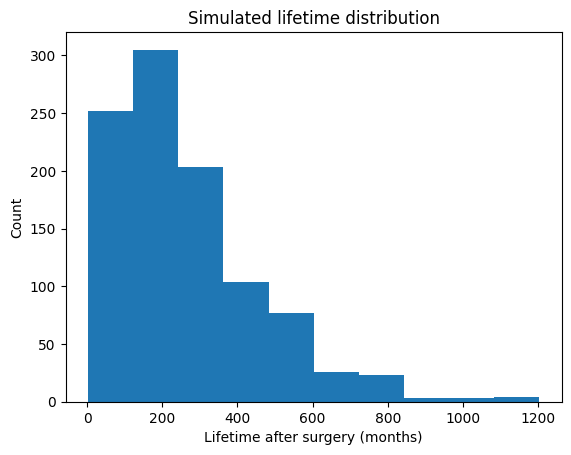

In [4]:
n_women = 1000

results = [contMarkov(Q) for i in range(n_women)]

lifetimes = np.array([t for t,track in results])
trackings = [track for t,track in results]

plt.hist(lifetimes)
plt.xlabel("Lifetime after surgery (months)")
plt.ylabel("Count")
plt.title("Simulated lifetime distribution")
plt.show()

In [5]:
obs_interval = 48

obs_women = []
for track in trackings:
    obs_woman = []
    
    t = 0
    s = 1
    while s != 5:
        for time, state in track:
            if time <= t:
                s = state
            else:
                break
        
        t += obs_interval
        obs_woman.append(s)

    obs_women.append(obs_woman)

## Task 13

In [6]:
def contMarkov_int(Q,start,end,obs_interval):
    while True:
        t = 0
        s = start
        track = [(0,s)]
        while s != 5 and t < obs_interval:
            t_sojourn = np.random.exponential(scale = 1/-Q[s-1][s-1])
            t += t_sojourn
            
            if t >= obs_interval:
                break

            s_pos = np.delete(states,s-1)

            probs = []
            for x in s_pos:
                probs.append(-Q[s-1][x-1]/Q[s-1][s-1])

            s_next = int(np.random.choice(s_pos, p=probs))
            s = s_next

            track.append((t, s))

        if s == end:
            return track

In [7]:
Q_k = np.array([[-0.03,  0.01,  0.01,  0.00,  0.01],
                [ 0.00, -0.03,  0.01,  0.01,  0.01],
                [ 0.00,  0.00, -0.02,  0.01,  0.01],
                [ 0.00,  0.00,  0.00, -0.01,  0.01],
                [ 0.00,  0.00,  0.00,  0.00,  0.00]])

N_k,_ = Q_k.shape

states = np.arange(1,N_k+1)

#1. Trajectories
trajs_women = []
for obs in obs_women:
    time_offset = 0
    
    traj_woman = []
    for i in range(len(obs)-1):
        path = contMarkov_int(Q_cur,obs[i],obs[i+1],obs_interval)

        for time,state in path:
            traj_woman.append((time+time_offset,state))

        time_offset += obs_interval

    trajs_women.append(traj_woman)

#2. Summarize N and S
N = np.zeros((N_k,N_k))
S = np.zeros(N_k)

for traj in trajs_women:
    for k in range(len(traj)-1):

        t_cur,s_cur = traj[k]
        t_next,s_next = traj[k+1]

        t_sojourn = t_next-t_cur

        S[s_cur-1] += t_sojourn

        if s_cur != s_next:
            N[s_cur-1,s_next-1] += 1

#3. Find Q_k+1 (Q_next)
Q_next = np.zeros((N_k,N_k))

for i in range(N_k):
    if S[i] > 0:
        for j in range(N_k):
            if i != j:
                Q_next[i,j] = N[i,j] / S[i]

    Q_next[i,i] = -np.sum(Q_next[i,:])

#Repeat until convergence
Q_cur = Q_k.copy()

while np.linalg.norm(Q_next-Q_cur,1) > 1e-3:

    Q_cur = Q_next.copy()

In [ ]:
#Combined:
Q_cur = Q_k.copy()
while True:
    #1. Trajectories
    trajs_women = []
    for obs in obs_women:
        time_offset = 0
        
        traj_woman = []
        for i in range(len(obs)-1):
            path = contMarkov_int(Q_cur,obs[i],obs[i+1],obs_interval)

            for time,state in path:
                traj_woman.append((time+time_offset,state))

            time_offset += obs_interval

        trajs_women.append(traj_woman)

    #2. Summarize N and S
    N = np.zeros((N_k,N_k))
    S = np.zeros(N_k)

    for traj in trajs_women:
        for k in range(len(traj)-1):

            t_cur,s_cur = traj[k]
            t_next,s_next = traj[k+1]

            t_sojourn = t_next-t_cur

            S[s_cur-1] += t_sojourn

            if s_cur != s_next:
                N[s_cur-1,s_next-1] += 1

    #3. Find Q_k+1 (Q_next)
    Q_next = np.zeros((N_k,N_k))

    for i in range(N_k):
        if S[i] > 0:
            for j in range(N_k):
                if i != j:
                    Q_next[i,j] = N[i,j] / S[i]

        Q_next[i,i] = -np.sum(Q_next[i,:])
    
    #Repeat until convergence
    if np.linalg.norm(Q_cur-Q_next,1) < 1e-3:
        break
    
    Q_cur = Q_next.copy()

Q_estimate = Q_next

print(Q_estimate)
print(Q)


[[-0.00841762  0.00502532  0.00244111  0.          0.00095119]
 [ 0.         -0.01366365  0.00565314  0.00341019  0.00460033]
 [ 0.          0.         -0.00848707  0.00338218  0.00510489]
 [ 0.          0.          0.         -0.00976888  0.00976888]
 [ 0.          0.          0.          0.         -0.        ]]
[[-0.0085  0.005   0.0025  0.      0.001 ]
 [ 0.     -0.014   0.005   0.004   0.005 ]
 [ 0.      0.     -0.008   0.003   0.005 ]
 [ 0.      0.      0.     -0.009   0.009 ]
 [ 0.      0.      0.      0.      0.    ]]
